# FC 26 player dataset: exploratory data analysis

This notebook profiles the raw Kaggle FC 26 player snapshot used by the Career Mode recommender. It focuses on:

- what one row represents and whether that grain is unique,
- dataset structure and player coverage,
- missingness, duplicates, identifiers, and category consistency, and
- distributions that will matter when player and squad features are designed later.

This is read-only EDA: the raw CSV is never modified, and no recommendation scoring is implemented.

In [1]:
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

def find_project_root(start: Path) -> Path:
    """Find the repository root from either the root or notebooks directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "data" / "raw").is_dir() and (candidate / "docs" / "PLAN.md").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
csv_files = sorted(RAW_DATA_DIR.glob("*.csv"))
if len(csv_files) != 1:
    raise ValueError(f"Expected exactly one raw CSV, found {len(csv_files)}: {csv_files}")

DATA_PATH = csv_files[0]
DATA_PATH.relative_to(PROJECT_ROOT)

PosixPath('data/raw/FC26_20250921.csv')

In [2]:
players = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {len(players):,} rows and {players.shape[1]:,} columns from {DATA_PATH.name}.")

Loaded 18,405 rows and 110 columns from FC26_20250921.csv.


## 1. Dataset structure and row grain

The likely grain is **one player in one FC database update**. The checks below test that interpretation using the snapshot fields and `player_id`, rather than assuming it from the filename. Names are descriptive attributes and are not expected to be unique.

In [3]:
snapshot_columns = ["fifa_version", "fifa_update", "fifa_update_date"]
display(players[snapshot_columns].drop_duplicates().reset_index(drop=True))

grain_check = pd.Series({
    "rows": len(players),
    "columns": players.shape[1],
    "non-null player IDs": players["player_id"].notna().sum(),
    "unique player IDs": players["player_id"].nunique(dropna=True),
    "duplicate player-ID rows": players.duplicated("player_id", keep=False).sum(),
    "exact duplicate rows": players.duplicated().sum(),
    "unique long names": players["long_name"].nunique(dropna=True),
}, name="count").to_frame()
display(grain_check)

,fifa_version,fifa_update,fifa_update_date
0,26,4,2025-09-19


,count
rows,18405
columns,110
non-null player IDs,18405
unique player IDs,18405
duplicate player-ID rows,0
exact duplicate rows,0
unique long names,18385


**Row interpretation.** In this file, one row represents one uniquely identified player in FC 26 update 4, dated 2025-09-19. `player_id` is complete and unique at this snapshot. If multiple update files are combined later, the safe longitudinal key should be `(player_id, fifa_update)` or `(player_id, fifa_update_date)`, not `player_id` alone.

In [4]:
example_columns = [
    "player_id", "short_name", "long_name", "age", "club_name",
    "league_name", "player_positions", "overall", "potential",
    "value_eur", "wage_eur", "player_traits"
]
display(players.loc[[0], example_columns].T.rename(columns={0: "example row"}))

,example row
player_id,252371
short_name,J. Bellingham
long_name,Jude Victor William Bellingham
age,22
club_name,Real Madrid
league_name,La Liga
player_positions,"CAM, CM"
overall,90
potential,94
value_eur,174500000


In [5]:
schema = pd.DataFrame({
    "dtype": players.dtypes.astype(str),
    "non_null": players.notna().sum(),
    "missing": players.isna().sum(),
    "missing_pct": players.isna().mean().mul(100),
    "unique_non_null": players.nunique(dropna=True),
})
schema.index.name = "column"

display(
    schema["dtype"]
    .value_counts()
    .rename_axis("dtype")
    .to_frame("columns")
)
display(HTML(
    f"<details><summary>Show all {len(schema)} columns and dtypes</summary>"
    f"{schema.to_html()}</details>"
))

,columns
dtype,
int64,48
str,46
float64,16


,dtype,non_null,missing,missing_pct,unique_non_null
column,,,,,
player_id,int64,18405,0,0.00,18405
player_url,str,18405,0,0.00,18405
fifa_version,int64,18405,0,0.00,1
fifa_update,int64,18405,0,0.00,1
fifa_update_date,str,18405,0,0.00,1
short_name,str,18405,0,0.00,17596
long_name,str,18405,0,0.00,18385
player_positions,str,18405,0,0.00,647
overall,int64,18405,0,0.00,45


## 2. Coverage

`player_positions` is a comma-separated ordered list: the first token is treated as the primary position and all tokens describe playable positions. The raw `player_traits` field contains the game's PlayStyles, including `+` variants. Those lists are exploded below without changing the raw dataframe.

In [6]:
def explode_tokens(frame: pd.DataFrame, column: str, token_name: str) -> pd.DataFrame:
    """Return one stripped comma-delimited token per player and row."""
    exploded = (
        frame.loc[frame[column].notna(), ["player_id", column]]
        .assign(**{token_name: lambda data: data[column].str.split(",")})
        .explode(token_name)
    )
    exploded[token_name] = (
        exploded[token_name].astype("string").str.replace("\u00a0", " ", regex=False).str.strip()
    )
    return exploded[["player_id", token_name]].drop_duplicates()

position_rows = explode_tokens(players, "player_positions", "position")
primary_positions = players["player_positions"].str.split(",").str[0].str.strip()
playstyle_rows = explode_tokens(players, "player_traits", "playstyle")
playstyle_rows["is_plus"] = playstyle_rows["playstyle"].str.endswith("+")
playstyle_rows["playstyle_base"] = playstyle_rows["playstyle"].str.removesuffix("+").str.strip()

coverage = pd.Series({
    "players": players["player_id"].nunique(),
    "clubs": players["club_name"].nunique(dropna=True),
    "leagues": players["league_name"].nunique(dropna=True),
    "division levels": players["league_level"].nunique(dropna=True),
    "playable position tokens": position_rows["position"].nunique(),
    "players with at least one PlayStyle": playstyle_rows["player_id"].nunique(),
    "distinct PlayStyle labels (including +)": playstyle_rows["playstyle"].nunique(),
    "distinct base PlayStyles": playstyle_rows["playstyle_base"].nunique(),
}, name="count").to_frame()
display(coverage)

,count
players,18405
clubs,662
leagues,42
division levels,4
playable position tokens,12
players with at least one PlayStyle,7616
distinct PlayStyle labels (including +),71
distinct base PlayStyles,36


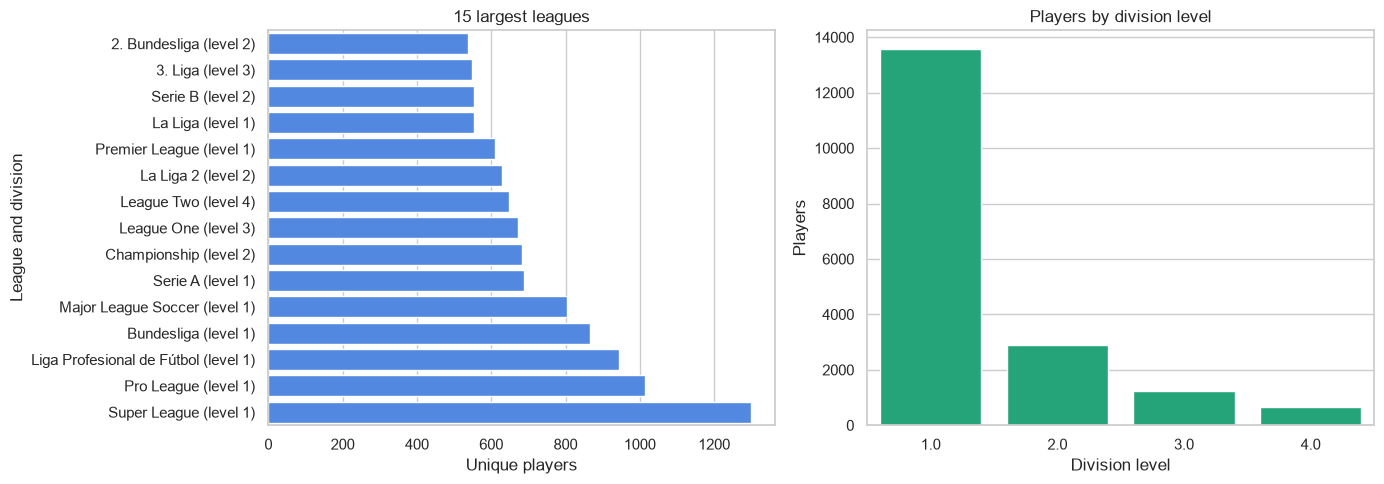

In [7]:
league_coverage = (
    players.groupby(["league_name", "league_level"], dropna=False)
    .agg(clubs=("club_name", "nunique"), players=("player_id", "nunique"))
    .sort_values("players", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
largest_leagues = league_coverage.head(15).reset_index().sort_values("players")
largest_leagues["league_division"] = (
    largest_leagues["league_name"]
    + " (level "
    + largest_leagues["league_level"].astype(int).astype(str)
    + ")"
)
sns.barplot(
    data=largest_leagues,
    x="players",
    y="league_division",
    color="#3b82f6",
    ax=axes[0],
)
axes[0].set(
    title="15 largest leagues",
    xlabel="Unique players",
    ylabel="League and division",
)
division_counts = (
    players["league_level"]
    .value_counts()
    .sort_index()
    .rename_axis("league_level")
    .reset_index(name="players")
)
sns.barplot(
    data=division_counts,
    x="league_level",
    y="players",
    color="#10b981",
    ax=axes[1],
)
axes[1].set(
    title="Players by division level",
    xlabel="Division level",
    ylabel="Players",
)
plt.tight_layout()
plt.show()

,primary_position_players,playable_position_players
CM,2214,5238
CB,3326,4203
RM,1016,4064
LM,1064,3954
ST,2534,3414
CAM,1137,3066
CDM,1433,2999
RB,1423,2292
LB,1367,2230
GK,2062,2062


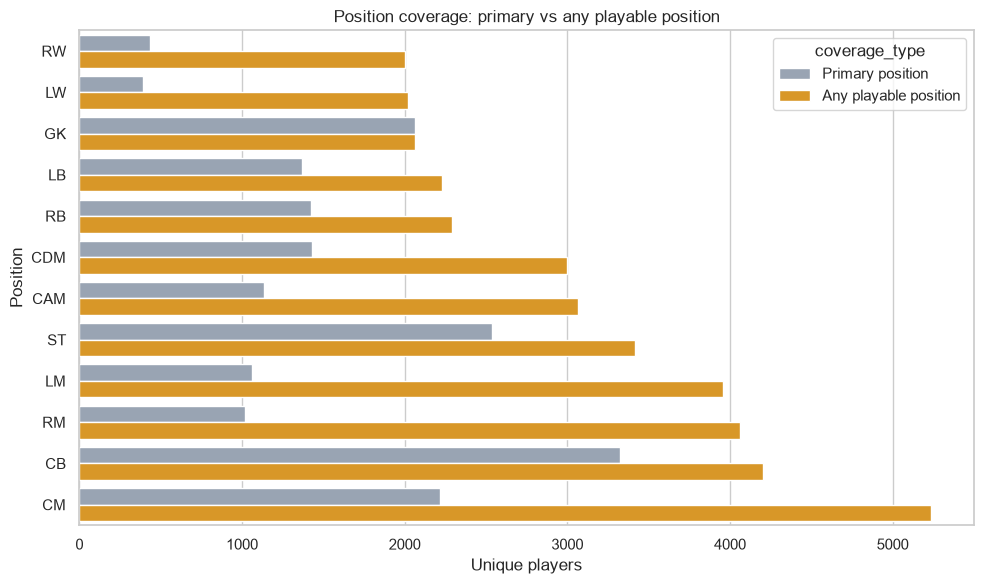

In [8]:
position_coverage = pd.concat([
    primary_positions.value_counts().rename("primary_position_players"),
    position_rows.groupby("position")["player_id"].nunique().rename("playable_position_players"),
], axis=1).fillna(0).astype(int).sort_values("playable_position_players", ascending=False)
display(position_coverage)

position_order = position_coverage.sort_values("playable_position_players").index
position_coverage_long = (
    position_coverage.rename_axis("position").reset_index()
    .melt(id_vars="position", var_name="coverage_type", value_name="players")
    .replace({"coverage_type": {
        "primary_position_players": "Primary position",
        "playable_position_players": "Any playable position",
    }})
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=position_coverage_long, x="players", y="position", hue="coverage_type",
    order=position_order, palette=["#94a3b8", "#f59e0b"]
)
plt.title("Position coverage: primary vs any playable position")
plt.xlabel("Unique players")
plt.ylabel("Position")
plt.tight_layout()
plt.show()

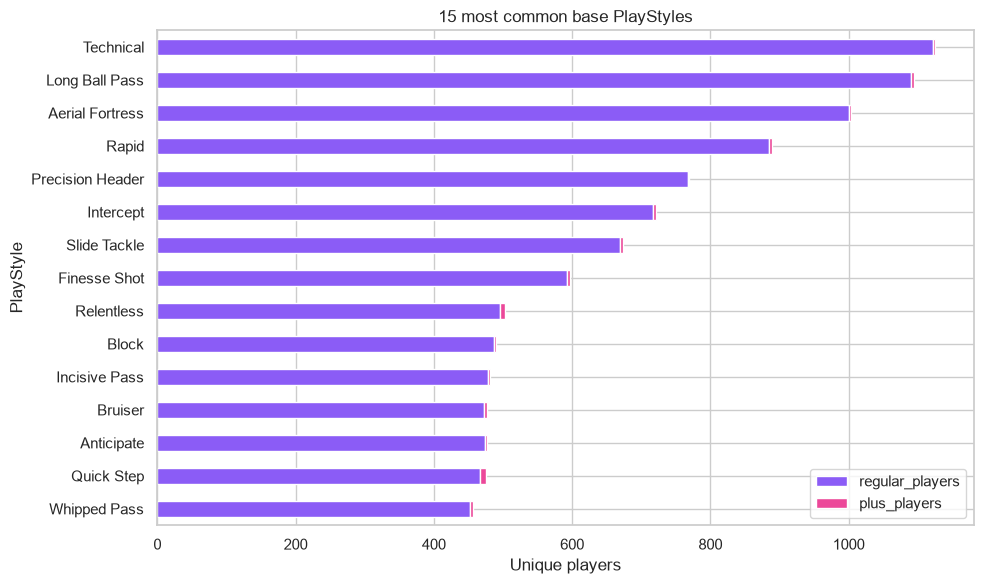

In [9]:
playstyle_coverage = (
    playstyle_rows.groupby("playstyle_base")
    .agg(
        players=("player_id", "nunique"),
        plus_players=("is_plus", "sum"),
    )
    .assign(regular_players=lambda data: data["players"] - data["plus_players"])
    .sort_values("players", ascending=False)
)

playstyle_coverage.head(15).sort_values("players")[["regular_players", "plus_players"]].plot.barh(
    stacked=True,
    figsize=(10, 6),
    color=["#8b5cf6", "#ec4899"],
)
plt.title("15 most common base PlayStyles")
plt.xlabel("Unique players")
plt.ylabel("PlayStyle")
plt.tight_layout()
plt.show()

## 3. Data quality

Missing values are shown across all columns. Zero is kept distinct from missing because zero value/wage can carry a different meaning, especially for unattached players.

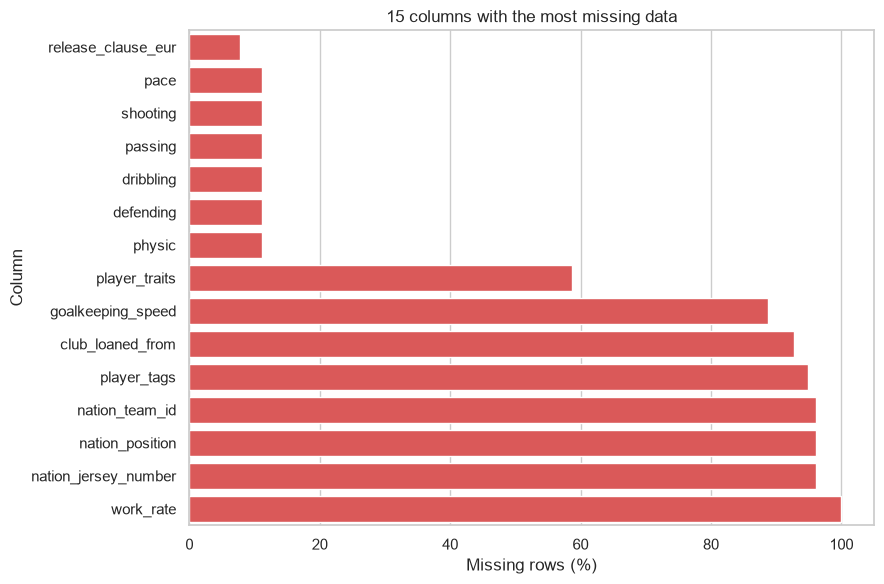

,dtype,missing,missing_pct
column,,,
work_rate,float64,18405,100.00
nation_team_id,float64,17677,96.04
nation_position,str,17677,96.04
nation_jersey_number,float64,17677,96.04
player_tags,str,17455,94.84
club_loaned_from,str,17080,92.80
goalkeeping_speed,float64,16343,88.80
player_traits,str,10789,58.62
pace,float64,2062,11.20


In [10]:
missingness = (
    schema.loc[schema["missing"].gt(0), ["dtype", "missing", "missing_pct"]]
    .sort_values(["missing_pct", "missing"], ascending=False)
)

missingness_plot = missingness.head(15).sort_values("missing_pct").reset_index()
plt.figure(figsize=(9, 6))
sns.barplot(
    data=missingness_plot,
    x="missing_pct",
    y="column",
    color="#ef4444",
)
plt.title("15 columns with the most missing data")
plt.xlabel("Missing rows (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

display(HTML(
    f"<details><summary>Show all {len(missingness)} columns with missing values</summary>"
    f"{missingness.to_html()}</details>"
))

In [11]:
duplicate_summary = pd.Series({
    "exact duplicate rows": players.duplicated().sum(),
    "rows involved in duplicate player_id groups": players.duplicated("player_id", keep=False).sum(),
    "missing player_id": players["player_id"].isna().sum(),
    "rows involved in duplicate long_name groups": players.duplicated("long_name", keep=False).sum(),
    "rows involved in duplicate short_name groups": players.duplicated("short_name", keep=False).sum(),
}, name="rows").to_frame()
display(duplicate_summary)

,rows
exact duplicate rows,0
rows involved in duplicate player_id groups,0
missing player_id,0
rows involved in duplicate long_name groups,40
rows involved in duplicate short_name groups,1460


Duplicate names are legitimate people and demonstrate why names should not be identifiers. Category checks below canonicalize Unicode, non-breaking spaces, repeated whitespace, outer whitespace, and case only for comparison. They report raw spellings that would collapse to the same canonical label; they do not overwrite the source values.

In [12]:
def canonicalize_text(value: str) -> str:
    """Canonicalize a category for inconsistency detection."""
    normalized = unicodedata.normalize("NFKC", str(value)).replace("\u00a0", " ")
    return re.sub(r"\s+", " ", normalized).strip().casefold()

def variant_groups(series: pd.Series) -> pd.Series:
    values = series.dropna().astype(str)
    groups = values.groupby(values.map(canonicalize_text)).agg(lambda group: sorted(set(group)))
    return groups[groups.map(len).gt(1)]

category_checks = []
for column in ["club_name", "league_name", "player_positions", "player_traits", "player_tags"]:
    values = players[column].dropna().astype(str)
    category_checks.append({
        "column": column,
        "raw_unique": values.nunique(),
        "canonical_unique": values.map(canonicalize_text).nunique(),
        "variant_groups": len(variant_groups(values)),
        "rows_with_outer_whitespace": values.ne(values.str.strip()).sum(),
        "rows_with_nonbreaking_space": values.str.contains("\u00a0", regex=False).sum(),
    })
category_quality = pd.DataFrame(category_checks).set_index("column")
display(category_quality)

expected_positions = {"GK", "RB", "CB", "LB", "CDM", "CM", "CAM", "RM", "LM", "RW", "LW", "ST"}
unexpected_positions = sorted(set(position_rows["position"]) - expected_positions)
print("Unexpected position tokens:", unexpected_positions or "None")

,raw_unique,canonical_unique,variant_groups,rows_with_outer_whitespace,rows_with_nonbreaking_space
column,,,,,
club_name,662,662,0,0,0
league_name,42,42,0,0,0
player_positions,647,647,0,0,0
player_traits,1762,1762,0,0,0
player_tags,61,61,0,26,53


Unexpected position tokens: None


In [13]:
id_consistency = pd.Series({
    "club IDs mapped to multiple club names": (
        players.dropna(subset=["club_team_id", "club_name"]).groupby("club_team_id")["club_name"].nunique().gt(1).sum()
    ),
    "club names mapped to multiple club IDs": (
        players.dropna(subset=["club_team_id", "club_name"]).groupby("club_name")["club_team_id"].nunique().gt(1).sum()
    ),
    "league IDs mapped to multiple league names": (
        players.dropna(subset=["league_id", "league_name"]).groupby("league_id")["league_name"].nunique().gt(1).sum()
    ),
    "league names mapped to multiple league IDs": (
        players.dropna(subset=["league_id", "league_name"]).groupby("league_name")["league_id"].nunique().gt(1).sum()
    ),
}, name="conflicting mappings").to_frame()
display(id_consistency)

league_name_id_conflicts = (
    players.dropna(subset=["league_id", "league_name"])
    .groupby("league_name")
    .agg(league_ids=("league_id", lambda values: sorted(values.astype(int).unique())),
         id_count=("league_id", "nunique"))
    .query("id_count > 1")
    .sort_values("id_count", ascending=False)
)
display(league_name_id_conflicts)

clubless = players.loc[players["club_name"].isna()]
clubless_summary = pd.Series({
    "players without a club": len(clubless),
    "also missing league": clubless["league_name"].isna().sum(),
    "zero wage": clubless["wage_eur"].eq(0).sum(),
    "zero market value": clubless["value_eur"].eq(0).sum(),
}, name="rows").to_frame()
display(clubless_summary)

,conflicting mappings
club IDs mapped to multiple club names,0
club names mapped to multiple club IDs,0
league IDs mapped to multiple league names,0
league names mapped to multiple league IDs,6


,league_ids,id_count
league_name,,
Super League,"[63, 189, 2012, 2149]",4
Pro League,"[4, 350, 2013]",3
Bundesliga,"[19, 80]",2
Premier League,"[13, 332]",2
Primera Division,"[335, 2019]",2
Serie A,"[31, 2018]",2


,rows
players without a club,89
also missing league,89
zero wage,89
zero market value,89


## 4. Recommendation-relevant distributions

These are descriptive checks only. Value and wage are strongly right-skewed, so the plots use `log1p` while the table remains in euros. Potential growth (`potential - overall`) is included because it helps distinguish immediate quality from development headroom.

In [14]:
players = players.assign(potential_growth=players["potential"] - players["overall"])
distribution_columns = ["overall", "potential", "potential_growth", "age", "value_eur", "wage_eur"]
distribution_summary = players[distribution_columns].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T
display(distribution_summary)
display(pd.Series({
    "zero market value": players["value_eur"].eq(0).sum(),
    "zero wage": players["wage_eur"].eq(0).sum(),
    "negative potential growth": players["potential_growth"].lt(0).sum(),
}, name="players").to_frame())

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
overall,"18,405.00",65.77,6.98,47.00,49.00,54.00,61.00,66.00,70.00,77.00,83.00,91.00
potential,"18,405.00",71.17,6.40,49.00,56.00,61.00,67.00,71.00,75.00,82.00,86.00,95.00
potential_growth,"18,405.00",5.40,5.53,0.00,0.00,0.00,0.00,4.00,9.00,16.00,20.00,26.00
age,"18,405.00",25.22,4.77,16.00,17.00,18.00,21.00,25.00,29.00,34.00,37.00,44.00
value_eur,"18,405.00","2,931,633.36","7,947,786.78",0.00,"50,000.00","130,000.00","475,000.00","1,000,000.00","2,100,000.00","12,000,000.00","36,500,000.00","174,500,000.00"
wage_eur,"18,405.00","10,096.06","20,082.98",0.00,500.00,500.00,"1,000.00","4,000.00","10,000.00","40,000.00","100,000.00","610,000.00"


,players
zero market value,109
zero wage,89
negative potential growth,0


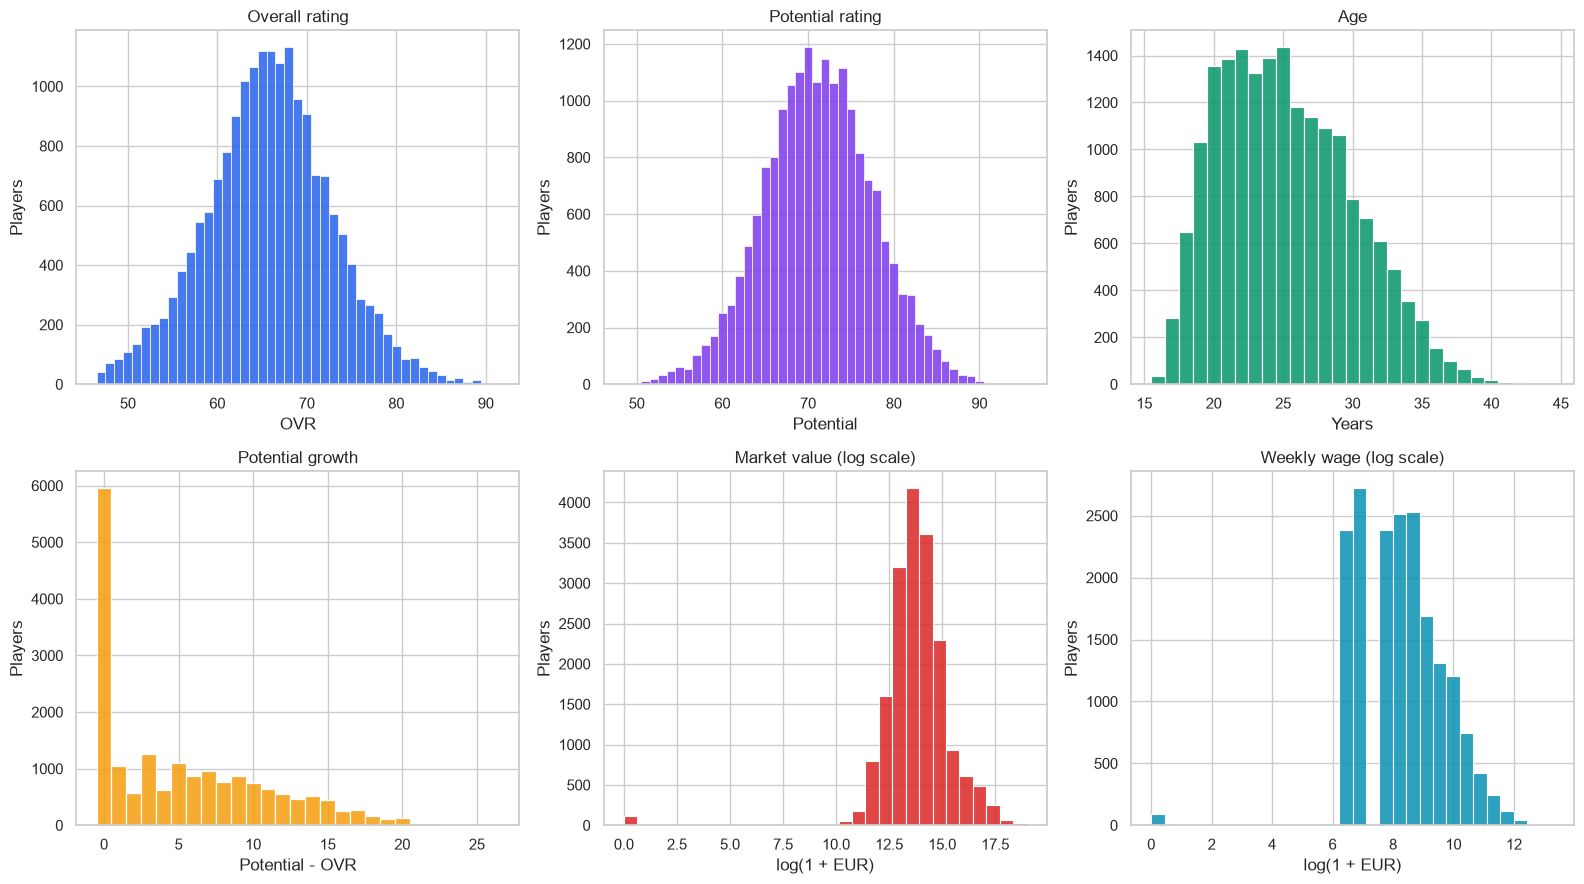

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    (players["overall"], "Overall rating", "OVR", "#2563eb", True),
    (players["potential"], "Potential rating", "Potential", "#7c3aed", True),
    (players["age"], "Age", "Years", "#059669", True),
    (players["potential_growth"], "Potential growth", "Potential - OVR", "#f59e0b", True),
    (np.log1p(players["value_eur"]), "Market value (log scale)", "log(1 + EUR)", "#dc2626", False),
    (np.log1p(players["wage_eur"]), "Weekly wage (log scale)", "log(1 + EUR)", "#0891b2", False),
]
for ax, (values, title, xlabel, color, discrete) in zip(axes.flat, plot_specs):
    plot_options = {"discrete": True} if discrete else {"bins": 30}
    sns.histplot(x=values.dropna(), color=color, alpha=0.85, edgecolor="white", ax=ax, **plot_options)
    ax.set(title=title, xlabel=xlabel, ylabel="Players")
plt.tight_layout()
plt.show()

### Squad size and position depth

Squad size excludes records with no `club_name`. Position depth counts every player who lists the position anywhere in `player_positions`. The club-by-position grid includes zeroes, so a club with no listed player at a position is represented rather than silently omitted.

,squad_size
count,662.00
mean,27.67
std,3.46
min,18.00
5%,22.00
25%,26.00
50%,28.00
75%,30.00
95%,33.00
max,38.00


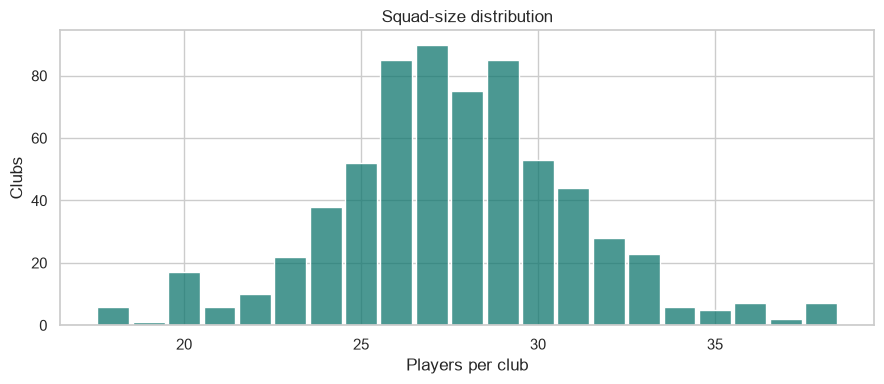

In [16]:
squad_sizes = (
    players.dropna(subset=["club_name"])
    .groupby("club_name")["player_id"]
    .nunique()
    .sort_values()
)
display(
    squad_sizes.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .to_frame("squad_size")
)

squad_size_frame = (
    squad_sizes.rename("squad_size")
    .rename_axis("club_name")
    .reset_index()
)
plt.figure(figsize=(9, 4))
sns.histplot(
    data=squad_size_frame,
    x="squad_size",
    discrete=True,
    shrink=0.9,
    color="#0f766e",
)
plt.title("Squad-size distribution")
plt.xlabel("Players per club")
plt.ylabel("Clubs")
plt.tight_layout()
plt.show()

,mean,median,clubs_with_zero_depth
position,,,
CAM,4.61,4.00,3
CB,6.32,6.00,0
CDM,4.51,5.00,1
CM,7.88,8.00,0
GK,3.10,3.00,0
LB,3.35,3.00,1
LM,5.95,6.00,0
LW,3.04,3.00,31
RB,3.44,3.00,0


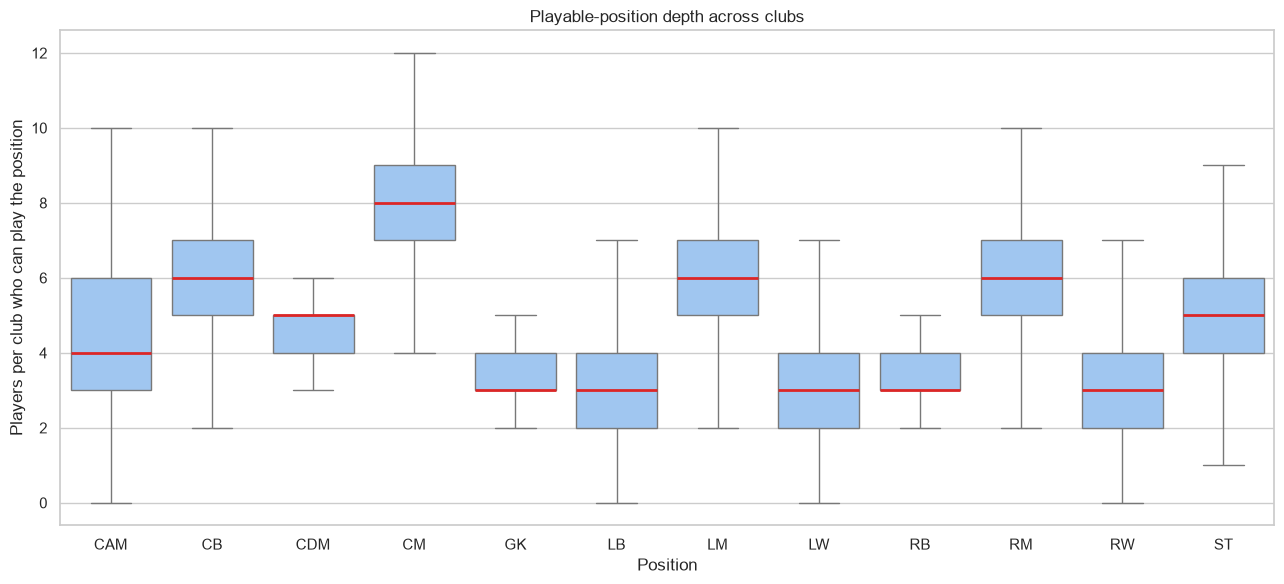

In [17]:
club_positions = (
    players.loc[players["club_name"].notna(), ["player_id", "club_name", "player_positions"]]
    .assign(position=lambda data: data["player_positions"].str.split(","))
    .explode("position")
)
club_positions["position"] = club_positions["position"].str.strip()
position_depth = (
    club_positions.groupby(["club_name", "position"])["player_id"].nunique()
    .unstack(fill_value=0)
    .reindex(columns=sorted(expected_positions))
)
depth_summary = position_depth.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
depth_summary["clubs_with_zero_depth"] = position_depth.eq(0).sum()
display(
    depth_summary[["mean", "50%", "clubs_with_zero_depth"]]
    .rename(columns={"50%": "median"})
)

position_depth_long = (
    position_depth.rename_axis("club_name").reset_index()
    .melt(id_vars="club_name", var_name="position", value_name="players")
)
plt.figure(figsize=(13, 6))
sns.boxplot(
    data=position_depth_long, x="position", y="players",
    showfliers=False, color="#93c5fd", medianprops={"color": "#dc2626", "linewidth": 2}
)
plt.title("Playable-position depth across clubs")
plt.xlabel("Position")
plt.ylabel("Players per club who can play the position")
plt.tight_layout()
plt.show()

## EDA takeaways

- The snapshot supports a player-level grain keyed by `player_id`; names are not identifiers.
- Primary and secondary positions need separate treatment. Using only the first position would substantially understate squad depth.
- `player_traits` should be renamed conceptually to PlayStyles during preprocessing, parsed as a list, and preserve the `+` tier separately from its base name.
- Missing club/league fields form a coherent unattached-player case and should not be handled the same way as arbitrary missing data.
- Zero market values and wages should be reviewed explicitly rather than automatically converted to missing values.
- Club, league, position, and PlayStyle labels are consistent under basic Unicode/whitespace/case checks in this snapshot. However, six generic league names map to more than one `league_id`, so league identity should be keyed by ID (or a documented composite) rather than name alone. `player_tags` also contains whitespace artifacts that preprocessing should normalize if that field is retained.
- Value and wage are highly skewed; robust scaling or log transformations will likely be more useful than raw euros in later phases.
- Position-depth features should use the full playable-position list and retain zero-depth club-position combinations.